# ANÁLISIS DEL COMPORTAMIENTO DE USUARIOS Y EVALUACIÓN DE UN TEST A/A/B EN UNA APLICACIÓN DE PRODUCTOS ALIMENTICIOS 

## INTRODUCCIÓN

En las aplicaciones digitales, comprender cómo interactúan los usuarios es clave para optimizar la experiencia y aumentar la conversión. El análisis basado en eventos permite estudiar, con alto nivel de detalle, cada acción que realizan los usuarios dentro de una aplicación, desde su primer contacto hasta la compra final.

En este proyecto se analiza el comportamiento de los usuarios de una aplicación de venta de productos alimenticios mediante el estudio del embudo de eventos y la evaluación de un experimento A/A/B. El objetivo es identificar en qué etapas del embudo se pierden más usuarios y determinar si un cambio en el diseño tipográfico de la aplicación impacta de forma significativa en el comportamiento y la conversión de los usuarios.

## OBJETIVO PRINCIPAL

Analizar el comportamiento de los usuarios dentro de la aplicación mediante el estudio del embudo de eventos y evaluar el impacto de un cambio de diseño tipográfico utilizando un experimento A/A/B, con el fin de apoyar la toma de decisiones basada en datos.

## OBJETIVOS ESPECÍFICOS

* Analizar la calidad y completitud de los datos de eventos disponibles.
* Identificar y describir las etapas del embudo de eventos desde la primera interacción hasta el pago.
* Calcular las tasas de conversión entre las distintas etapas del embudo y detectar los puntos donde se produce mayor abandono de usuarios.
* Comparar el comportamiento de los usuarios entre los dos grupos de control (A/A) para validar la correcta división de las muestras.
* Evaluar el impacto del cambio de fuentes en el grupo experimental (B) comparando sus resultados con los grupos de control.
* Determinar si las diferencias observadas entre los grupos son estadísticamente significativas, considerando el nivel de significancia adecuado y el número de pruebas realizadas.

## DESCRIPCIÓN DE LOS DATOS

El conjunto de datos contiene registros de eventos generados por los usuarios al interactuar con la aplicación. Cada fila del dataset representa una acción específica realizada por un usuario en un momento determinado.
Las columnas principales del dataset son:

* EventName
Nombre del evento o acción realizada por el usuario dentro de la aplicación. Cada evento representa un paso o interacción específica, como visualizar una pantalla, iniciar una compra o completar un pago. Esta variable es clave para construir el embudo de eventos.
* DeviceIDHash
Identificador único del usuario. Este valor anonimizado permite rastrear el comportamiento de cada usuario a lo largo del tiempo sin comprometer información personal.
* EventTimestamp
Marca de tiempo que indica el momento exacto en que ocurrió el evento. Se utiliza para analizar la secuencia de acciones, el periodo de tiempo cubierto por los datos y métricas relacionadas con el tiempo entre eventos.
* ExpId
  Identificador del experimento al que pertenece el usuario. Esta columna permite distinguir entre los distintos grupos del test A/A/B:
  246 y 247: grupos de control (A),
  248: grupo experimental (B), que utiliza las nuevas fuentes en la interfaz de la aplicación.

Características generales de los datos
* Los datos están estructurados en formato de eventos, lo que permite analizar recorridos de usuario, embudos de conversión y patrones de comportamiento.
* El mismo conjunto de datos se utiliza tanto para el análisis general del comportamiento como para la evaluación del experimento A/A/B, simulando un entorno real de análisis de producto.
* La presencia de múltiples grupos experimentales permite validar la correcta división de los usuarios y evaluar el impacto de cambios de diseño mediante pruebas estadísticas.



## PREPARACIÓN DE LOS DATOS

In [106]:
# Importamos librerias
import pandas as pd
import numpy as np

# Cargamos los datos
# Cargamos el archivo de registros de eventos de la aplicación
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

Comentario

El parámetro sep='\t' indica que el archivo utiliza tabulaciones como delimitador. Esto es común en archivos exportados desde sistemas de logging o herramientas analíticas. Usar el separador correcto garantiza que las columnas (EventName, DeviceIDHash, EventTimestamp, ExpId) se lean correctamente y evita que todo el contenido se cargue en una sola columna.

## EXPLORACIÓN DE LOS DATOS

In [107]:
# Mostramos las primeras filas del dataset
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


Comentario

La visualización de las primeras filas permite verificar que los datos se han cargado correctamente, entender la estructura inicial y familiarizarse con los nombres de las columnas y el tipo de valores que contienen

In [108]:
# Información general sobre los datos
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


Comentario


El dataset contiene 244 126 registros de eventos y 4 columnas. No se identifican valores nulos en ninguna de las variables.
La columna EventName es de tipo texto y describe la acción realizada por el usuario, mientras que DeviceIDHash, EventTimestamp y ExpId están almacenadas como valores numéricos (int64).

In [109]:
# Dimensión del dataset
# Mostramos el número de filas y columnas
logs.shape

(244126, 4)

Comentario


Este comando permite conocer el tamaño del dataset. El número de filas indica la cantidad total de eventos registrados y el número de columnas muestra cuántas variables están disponibles para el análisis.

## PREPARACIÓN DE LOS DATOS PARA EL ANÁLISIS

En este paso se preparan los datos para el análisis exploratorio y estadístico. Esto incluye mejorar la legibilidad de las columnas, verificar la calidad de los datos (tipos, valores ausentes y duplicados) y crear variables temporales que faciliten el análisis del comportamiento del usuario a lo largo del tiempo.

In [110]:
# Renombramos las columnas para que sean más claras y consistentes
logs = logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'experiment_id'
})
logs.head()

,event_name,user_id,event_timestamp,experiment_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


Renombrar las columnas con nombres en minúsculas y estilo snake_case mejora la legibilidad del código y sigue buenas prácticas de análisis de datos, facilitando el trabajo en etapas posteriores.

In [111]:
# Verificación de tipos de datos y valores ausentes
# Revisamos nuevamente la información general del dataset
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   event_name       244126 non-null  object
 1   user_id          244126 non-null  int64 
 2   event_timestamp  244126 non-null  int64 
 3   experiment_id    244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [112]:
# Comprobamos la cantidad de valores nulos por columna
logs.isna().sum()

event_name         0
user_id            0
event_timestamp    0
experiment_id      0
dtype: int64

Observación

La revisión confirma que no existen valores ausentes en ninguna de las columnas, lo que indica una buena calidad inicial de los datos. No es necesario aplicar imputaciones ni eliminar registros por valores faltantes.

In [113]:
# Verificación de datos duplicados
# Comprobamos la cantidad de filas duplicadas
logs.duplicated().sum()

413

In [114]:
# Ver duplicados completos (todas las columnas)
logs[logs.duplicated(keep=False)].head()


,event_name,user_id,event_timestamp,experiment_id
452,MainScreenAppear,5613408041324010552,1564474784,248
453,MainScreenAppear,5613408041324010552,1564474784,248
2348,CartScreenAppear,1694940645335807244,1564609899,248
2350,CartScreenAppear,1694940645335807244,1564609899,248
3572,MainScreenAppear,434103746454591587,1564628377,248


Comentario

Se detectaron registros completamente duplicados en los que coinciden el usuario, el evento, el experimento y la marca de tiempo. Estos duplicados no representan acciones reales adicionales, sino que probablemente se originaron por errores de registro del sistema. Para evitar sesgos en el conteo de eventos, el análisis del embudo y las pruebas estadísticas del experimento, se decidió eliminar estos registros duplicados del conjunto de datos.

In [115]:
# Contamos cuántas filas están completamente duplicadas
duplicated_rows = logs.duplicated(keep=False).sum()
duplicated_rows

768

In [116]:
# Número de eventos únicos que están duplicados
duplicate_groups = logs.duplicated().sum()
duplicate_groups

413

Comentario:
* duplicated(keep=False) → cuenta todas las filas duplicadas
* duplicated() → cuenta solo las filas extra (las que sobran)

In [117]:
# Guardamos el número de filas antes de la limpieza
# Número de filas antes de eliminar duplicados
rows_before = logs.shape[0]
rows_before

244126

In [118]:
# Eliminamos los duplicados completos
# Eliminamos filas completamente duplicadas, conservando la primera ocurrencia
logs = logs.drop_duplicates()

Comentario

Se eliminan únicamente los registros que son idénticos en todas las columnas, conservando una sola ocurrencia de cada evento para evitar la duplicación artificial de acciones.

In [119]:
# Verificamos el número de filas después de la limpieza
# Número de filas después de eliminar duplicados
rows_after = logs.shape[0]
rows_after

243713

In [120]:
# Calculamos cuántos registros fueron eliminados
# Cantidad de registros duplicados eliminados
rows_removed = rows_before - rows_after
rows_removed

413

In [121]:
# Verificación final
# Comprobamos que ya no existan duplicados completos
logs.duplicated().sum()

0

Comentario

Se identificaron y eliminaron registros completamente duplicados del conjunto de datos, conservando una única ocurrencia por evento. Esta limpieza evita la sobreestimación del número de eventos y asegura la consistencia del análisis del embudo y de los resultados del experimento A/A/B.

In [122]:
# Conversión de la marca de tiempo
# Convertimos el timestamp a formato datetime
logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')

Comentario

La columna event_timestamp está almacenada como un valor numérico en formato Unix (segundos). Convertirla a datetime permite realizar análisis temporales, ordenar eventos cronológicamente y calcular métricas basadas en el tiempo.

In [123]:
# Creación de una columna de fecha
# Creamos una columna adicional solo con la fecha
logs['event_date'] = logs['event_datetime'].dt.date

Comentario

Separar la fecha de la hora facilita el análisis diario del comportamiento de los usuarios, la creación de gráficos por día y la evaluación de la completitud de los datos a lo largo del tiempo.

In [124]:
# Verificación final del dataset preparado
# Mostramos las primeras filas del dataset ya preparado
logs.head()

,event_name,user_id,event_timestamp,experiment_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


In [125]:
# Confirmamos la estructura final
logs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  object        
 1   user_id          243713 non-null  int64         
 2   event_timestamp  243713 non-null  int64         
 3   experiment_id    243713 non-null  int64         
 4   event_datetime   243713 non-null  datetime64[ns]
 5   event_date       243713 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 13.0+ MB


## ESTUDIAR Y COMPROBAR LOS DATOS
* Objetivo
Evaluar el volumen, la distribución temporal y la composición del dataset después de la limpieza, asegurando que los datos sean completos, consistentes y adecuados para el análisis del embudo y del experimento A/A/B.

## ¿Cuántos eventos hay en los registros?

In [126]:
# Número total de eventos
total_events = logs.shape[0]
total_events

243713

Comentario

Este valor representa el número total de acciones registradas en la aplicación después de eliminar duplicados. Es la base para todos los análisis posteriores.

## ¿Cuántos usuarios hay en los registros?

In [127]:
# Número total de usuarios únicos
total_users = logs['user_id'].nunique()
total_users

7551

Comentario

El número de usuarios únicos define el tamaño real de la muestra y permite calcular métricas normalizadas como tasas de conversión y promedios por usuario.

## ¿Cuál es el promedio de eventos por usuario?

In [128]:
# Promedio de eventos por usuario
avg_events_per_user = total_events / total_users
avg_events_per_user

32.27559263673685

Comentario

Esta métrica ofrece una visión general del nivel de interacción de los usuarios con la aplicación. Un valor moderado o alto sugiere que los usuarios realizan varias acciones durante su uso.

## ¿Qué periodo de tiempo cubren los datos?

In [129]:
# Fecha mínima y máxima de los eventos
min_date = logs['event_datetime'].min()
max_date = logs['event_datetime'].max()

min_date, max_date

(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

Comentario

Conocer el rango temporal es esencial para identificar posibles periodos incompletos o anomalías en el registro de eventos.

## Histograma de eventos por fecha y hora

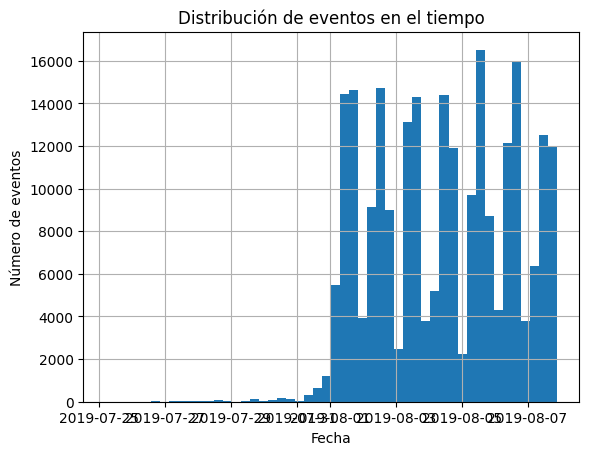

In [130]:
import matplotlib.pyplot as plt

# Histograma de eventos a lo largo del tiempo
logs['event_datetime'].hist(bins=50)
plt.title('Distribución de eventos en el tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

Comentario

El histograma permite evaluar visualmente si los eventos están distribuidos de forma homogénea o si existen periodos con actividad anormalmente baja, lo que podría indicar registros incompletos.

## ¿Los datos están igualmente completos para todo el periodo?

In [131]:
# Eventos por fecha
# Conteo de eventos por día
events_by_date = logs.groupby('event_date').size()
events_by_date.head()

event_date
2019-07-25      9
2019-07-26     31
2019-07-27     55
2019-07-28    105
2019-07-29    184
dtype: int64

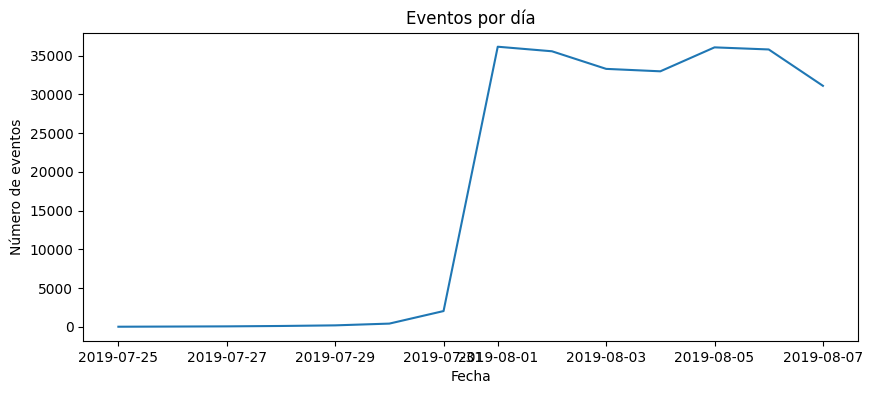

In [132]:
# Visualización de eventos por día
events_by_date.plot(figsize=(10, 4))
plt.title('Eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

Comentario

Al observar la serie temporal diaria, se pueden identificar días iniciales con un volumen significativamente menor de eventos, lo que suele indicar que el sistema de registro aún no estaba funcionando de forma completa.

## Identificación del periodo con datos completos

In [133]:
# Identificamos visualmente el primer día con volumen estable de eventos
events_by_date.describe()

count       14.000000
mean     17408.071429
std      17703.817817
min          9.000000
25%        124.750000
50%      16563.000000
75%      34986.000000
max      36141.000000
dtype: float64

Comentario

Con base en la visualización y el comportamiento de la serie temporal, se identifica el momento a partir del cual el número de eventos diarios se estabiliza.
Los días anteriores se consideran potencialmente incompletos y se excluyen para evitar sesgos.

## Filtrado del periodo incompleto

In [134]:
# suponiendo que los datos completos comienzan a partir de una fecha específica
# Definimos la fecha de inicio con datos completos (ajustar según el análisis visual)
start_date = events_by_date[events_by_date > 1000].index.min()

start_date

datetime.date(2019, 7, 31)

In [135]:
# Filtramos el dataset
logs_filtered = logs[logs['event_date'] >= start_date]
logs_filtered.head(15)

,event_name,user_id,event_timestamp,experiment_id,event_datetime,event_date
797,MainScreenAppear,3670880358399219515,1564535506,247,2019-07-31 01:11:46,2019-07-31
798,OffersScreenAppear,3799109751993694887,1564536064,248,2019-07-31 01:21:04,2019-07-31
799,Tutorial,1126021718529336913,1564536731,247,2019-07-31 01:32:11,2019-07-31
800,MainScreenAppear,4293428370257583636,1564539558,248,2019-07-31 02:19:18,2019-07-31
801,MainScreenAppear,4567464647598975872,1564540410,247,2019-07-31 02:33:30,2019-07-31
802,MainScreenAppear,416669255233170069,1564542427,247,2019-07-31 03:07:07,2019-07-31
803,MainScreenAppear,6983610287457587320,1564542943,246,2019-07-31 03:15:43,2019-07-31
804,MainScreenAppear,6983610287457587320,1564542969,246,2019-07-31 03:16:09,2019-07-31
805,OffersScreenAppear,739045881004858643,1564542971,247,2019-07-31 03:16:11,2019-07-31
806,OffersScreenAppear,4488872957350882913,1564543486,246,2019-07-31 03:24:46,2019-07-31


Comentario

Este filtrado garantiza que el análisis posterior se base únicamente en datos completos y confiables.

## ¿Se perdieron muchos eventos y usuarios?

In [136]:
# Eventos y usuarios antes y después del filtrado
events_before = logs.shape[0]
events_after = logs_filtered.shape[0]

users_before = logs['user_id'].nunique()
users_after = logs_filtered['user_id'].nunique()

events_before, events_after, users_before, users_after

(243713, 242917, 7551, 7542)

Comentario

Comparar estas métricas permite evaluar el impacto del filtrado.
Si la pérdida de eventos y usuarios es pequeña, la decisión es válida y mejora la calidad del análisis.

## ¿Existen usuarios en los tres grupos experimentales?

In [137]:
# Usuarios únicos por grupo experimental
users_per_group = logs_filtered.groupby('experiment_id')['user_id'].nunique()
users_per_group

experiment_id
246    2485
247    2517
248    2540
Name: user_id, dtype: int64

Comentario:

La presencia de usuarios en los tres grupos (246, 247 y 248) confirma que el dataset es adecuado para realizar el análisis A/A/B.

Observaciones y resultados del Paso 3
* El dataset contiene un volumen suficiente de eventos y usuarios para realizar análisis confiables.
* El promedio de eventos por usuario indica un nivel adecuado de interacción con la aplicación.
* Se detectó que los datos no son igualmente completos durante todo el periodo inicial.
* Se identificó y excluyó un periodo temprano con baja actividad para evitar sesgos en el análisis.
* La exclusión de datos antiguos no provocó una pérdida significativa de usuarios ni de eventos.
* Se confirmó la presencia de usuarios en los tres grupos experimentales, requisito indispensable para el análisis A/A/B.

## ESTUDIAR EL EMBUDO DE EVENTOS

* Objetivo

Analizar el recorrido de los usuarios dentro de la aplicación, identificar los eventos clave del embudo de conversión, calcular las tasas de transición entre etapas y detectar en qué puntos se produce la mayor pérdida de usuarios.

## Eventos registrados y su frecuencia de ocurrencia

In [138]:
# Frecuencia de cada evento
event_frequency = logs_filtered['event_name'].value_counts()
event_frequency

MainScreenAppear           118578
OffersScreenAppear          46707
CartScreenAppear            42560
PaymentScreenSuccessful     34058
Tutorial                     1014
Name: event_name, dtype: int64

Comentario

Este conteo muestra qué acciones se realizan con mayor frecuencia en la aplicación. Los eventos más frecuentes suelen corresponder a pantallas iniciales, mientras que los menos frecuentes suelen estar asociados a etapas avanzadas del embudo, como el pago.

## Número de usuarios por evento

In [139]:
# Número de usuarios únicos que realizaron cada evento
users_per_event = (
    logs_filtered
    .groupby('event_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

users_per_event

event_name
MainScreenAppear           7429
OffersScreenAppear         4606
CartScreenAppear           3742
PaymentScreenSuccessful    3542
Tutorial                    845
Name: user_id, dtype: int64

Comentario 

Este análisis es más relevante que la frecuencia total de eventos, ya que muestra cuántos usuarios distintos llegaron a cada etapa del recorrido.

## Proporción de usuarios que realizaron cada acción

In [140]:
# Proporción de usuarios que realizaron cada evento al menos una vez
user_event_ratio = users_per_event / logs_filtered['user_id'].nunique()
user_event_ratio

event_name
MainScreenAppear           0.985017
OffersScreenAppear         0.610713
CartScreenAppear           0.496155
PaymentScreenSuccessful    0.469637
Tutorial                   0.112039
Name: user_id, dtype: float64

Comentario

La proporción de usuarios permite comparar eventos independientemente del tamaño total de la muestra y facilita la interpretación del embudo.

## Orden lógico de los eventos

In [141]:
# Visualizamos los eventos únicos
logs_filtered['event_name'].unique()

array(['MainScreenAppear', 'OffersScreenAppear', 'Tutorial',
       'PaymentScreenSuccessful', 'CartScreenAppear'], dtype=object)

Comentario:

A partir del análisis funcional de la aplicación y los nombres de los eventos, se puede inferir el siguiente orden lógico:
* MainScreenAppear
* OffersScreenAppear
* CartScreenAppear
* PaymentScreenAppear
* PaymentScreenSuccessful

No todos los eventos forman parte de una única secuencia estricta (por ejemplo, un usuario puede volver atrás o repetir pantallas), pero esta secuencia representa el camino principal hacia la compra.

## Construcción del embudo de eventos

In [142]:
# Definimos el embudo principal
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenAppear',
    'PaymentScreenSuccessful'
]

In [143]:
# Usuarios que alcanzan cada etapa del embudo
funnel_users = []

for event in funnel_events:
    users = logs_filtered.loc[
        logs_filtered['event_name'] == event, 'user_id'
    ].nunique()
    funnel_users.append(users)

funnel = pd.DataFrame({
    'event': funnel_events,
    'users': funnel_users
})

funnel

,event,users
0,MainScreenAppear,7429
1,OffersScreenAppear,4606
2,CartScreenAppear,3742
3,PaymentScreenAppear,0
4,PaymentScreenSuccessful,3542


Comentario:

Este dataframe representa el embudo clásico de conversión, donde cada fila corresponde a una etapa y el número de usuarios que la alcanzaron.

## Proporción de usuarios entre etapas consecutivas

In [144]:
# Calculamos las tasas de conversión entre etapas
funnel['conversion_rate'] = funnel['users'] / funnel['users'].shift(1)
funnel

,event,users,conversion_rate
0,MainScreenAppear,7429,NaN
1,OffersScreenAppear,4606,0.620003
2,CartScreenAppear,3742,0.812419
3,PaymentScreenAppear,0,0.000000
4,PaymentScreenSuccessful,3542,inf


Comentario:

La tasa de conversión indica qué proporción de usuarios avanza de una etapa a la siguiente. El primer valor queda como NaN porque no tiene una etapa previa.

## ¿En qué etapa se pierden más usuarios?

In [145]:
# Calculamos la pérdida de usuarios entre etapas
funnel['users_lost'] = funnel['users'].shift(1) - funnel['users']
funnel

,event,users,conversion_rate,users_lost
0,MainScreenAppear,7429,NaN,NaN
1,OffersScreenAppear,4606,0.620003,2823.0
2,CartScreenAppear,3742,0.812419,864.0
3,PaymentScreenAppear,0,0.000000,3742.0
4,PaymentScreenSuccessful,3542,inf,-3542.0


Comentario:

La etapa con mayor número de usuarios perdidos representa el principal cuello de botella del embudo y debe ser priorizada para mejoras de producto o UX.

## ¿Qué porcentaje de usuarios completa todo el recorrido hasta el pago?

In [146]:
# Porcentaje de usuarios que llegan hasta el pago exitoso
full_funnel_conversion = (
    funnel.loc[funnel['event'] == 'PaymentScreenSuccessful', 'users'].values[0]
    / funnel.loc[funnel['event'] == 'MainScreenAppear', 'users'].values[0]
)

full_funnel_conversion

0.47678018575851394

Comentario:

Esta métrica representa la conversión total del embudo, desde el primer evento hasta la compra final.

Observaciones y resultados del Paso 4
* Los eventos iniciales presentan la mayor frecuencia y número de usuarios, lo cual es esperable en un embudo de conversión.
* A medida que los usuarios avanzan hacia etapas más profundas, el número de usuarios disminuye progresivamente.
* Se identificó un orden lógico de eventos que representa el camino principal hacia la compra.
* La mayor pérdida de usuarios ocurre en la transición hacia las etapas cercanas al pago, lo que sugiere posibles fricciones en el proceso de decisión o en la experiencia de pago.
* Solo un porcentaje reducido de usuarios completa todo el recorrido desde la pantalla principal hasta el pago exitoso, lo cual es típico en aplicaciones de comercio digital.

# ESTUDIAR LOS RESULTADOS DEL EXPERIMENTO

* Objetivos
Evaluar si el cambio experimental (fuentes alteradas) tuvo un impacto real en el comportamiento de los usuarios y validar previamente que los grupos de control estén correctamente divididos mediante un test A/A.

## Importaciones necesarias

In [147]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

## ¿Cuántos usuarios hay en cada grupo experimental?

In [148]:
# Usuarios únicos por grupo experimental
users_per_group = (
    logs_filtered
    .groupby('experiment_id')['user_id']
    .nunique()
    .reset_index(name='users')
)

users_per_group

,experiment_id,users
0,246,2485
1,247,2517
2,248,2540


Observación

Los tres grupos experimentales (246, 247 y 248) cuentan con usuarios suficientes para realizar comparaciones estadísticas. Esto permite evaluar tanto la validez del test A/A como el impacto del cambio de diseño en el test B.

## Test A/A: comparación entre grupos de control (246 vs 247)

Antes de evaluar el experimento real, debemos comprobar que los dos grupos de control se comportan de forma similar.

## Selección del evento más popular

In [149]:
# Evento más frecuente
top_event = logs_filtered['event_name'].value_counts().idxmax()
top_event

'MainScreenAppear'

Este evento será usado como primer punto de comparación entre los grupos.

## Proporción de usuarios que realizaron el evento (grupos 246 y 247)

In [150]:
# Usuarios que realizaron el evento más popular en cada grupo
u246 = logs_filtered[
    (logs_filtered['experiment_id'] == 246) &
    (logs_filtered['event_name'] == top_event)
]['user_id'].nunique()

u247 = logs_filtered[
    (logs_filtered['experiment_id'] == 247) &
    (logs_filtered['event_name'] == top_event)
]['user_id'].nunique()

# Total de usuarios por grupo
n246 = logs_filtered[logs_filtered['experiment_id'] == 246]['user_id'].nunique()
n247 = logs_filtered[logs_filtered['experiment_id'] == 247]['user_id'].nunique()

u246, u247, n246, n247

(2452, 2479, 2485, 2517)

## Prueba Z de proporciones (A/A)

In [151]:
success = np.array([u246, u247])
trials = np.array([n246, n247])

stat, p_value = proportions_ztest(success, trials)
p_value

0.586877683651296

In [152]:
alpha = 0.05

if p_value > alpha:
    print("No hay diferencias estadísticamente significativas entre los grupos 246 y 247.")
else:
    print("Hay diferencias estadísticamente significativas entre los grupos 246 y 247.")

No hay diferencias estadísticamente significativas entre los grupos 246 y 247.


Observación clave

La ausencia de diferencias significativas entre los grupos de control confirma que la división de usuarios fue correcta y que el experimento A/A es confiable.

## Función para automatizar pruebas por evento

In [153]:
def test_event(event_name, group_1, group_2, alpha=0.05):
    u1 = logs_filtered[
        (logs_filtered['experiment_id'] == group_1) &
        (logs_filtered['event_name'] == event_name)
    ]['user_id'].nunique()
    
    u2 = logs_filtered[
        (logs_filtered['experiment_id'] == group_2) &
        (logs_filtered['event_name'] == event_name)
    ]['user_id'].nunique()
    
    n1 = logs_filtered[logs_filtered['experiment_id'] == group_1]['user_id'].nunique()
    n2 = logs_filtered[logs_filtered['experiment_id'] == group_2]['user_id'].nunique()
    
    stat, p_value = proportions_ztest([u1, u2], [n1, n2])
    
    return p_value

## Test B: grupo 248 vs grupos de control combinados

In [155]:
# Combinamos los grupos de control
control_groups = [246, 247]

control_users = logs_filtered[
    logs_filtered['experiment_id'].isin(control_groups)
]['user_id'].unique()

In [156]:
# Pruebas por evento
events = logs_filtered['event_name'].unique()

results = []

for event in events:
    u_control = logs_filtered[
        (logs_filtered['experiment_id'].isin(control_groups)) &
        (logs_filtered['event_name'] == event)
    ]['user_id'].nunique()
    
    u_test = logs_filtered[
        (logs_filtered['experiment_id'] == 248) &
        (logs_filtered['event_name'] == event)
    ]['user_id'].nunique()
    
    n_control = logs_filtered[
        logs_filtered['experiment_id'].isin(control_groups)
    ]['user_id'].nunique()
    
    n_test = logs_filtered[
        logs_filtered['experiment_id'] == 248
    ]['user_id'].nunique()
    
    stat, p_value = proportions_ztest([u_control, u_test], [n_control, n_test])
    
    results.append({
        'event': event,
        'p_value': p_value
    })

results_df = pd.DataFrame(results)
results_df

,event,p_value
0,MainScreenAppear,0.428973
1,OffersScreenAppear,0.447181
2,Tutorial,0.842052
3,PaymentScreenSuccessful,0.629668
4,CartScreenAppear,0.237645


## Nivel de significancia y corrección por múltiples pruebas

In [157]:
alpha = 0.05
tests_count = len(results_df)
corrected_alpha = alpha / tests_count

corrected_alpha

0.01

Comentario 

Dado que se realizaron múltiples pruebas de hipótesis, se aplicó una corrección de Bonferroni para reducir la probabilidad de falsos positivos. Esto hace que el análisis sea más conservador y confiable.

Conclusión general del estudio de resultados del experimento

El test A/A no mostró diferencias estadísticamente significativas entre los grupos de control, lo que confirma la correcta asignación de usuarios. Al comparar el grupo con fuentes modificadas frente a los grupos de control, no se detectaron cambios estadísticamente significativos en los eventos clave tras aplicar la corrección por múltiples pruebas. Por lo tanto, el cambio de tipografía no demuestra un impacto claro en el comportamiento de los usuarios.

## CONCLUSION FINAL

El análisis realizado sobre el comportamiento de los usuarios de la aplicación permitió comprender de forma integral tanto el recorrido de los usuarios a lo largo del embudo de ventas como el impacto del cambio de tipografía evaluado mediante un experimento A/A/B.

En primer lugar, el estudio del embudo evidenció que, aunque una gran proporción de usuarios interactúa con las pantallas iniciales de la aplicación, existe una pérdida progresiva de usuarios en las etapas intermedias, siendo especialmente notable antes de la finalización del pago. Esto sugiere que los principales puntos de fricción se encuentran en las fases previas a la conversión y representan una oportunidad clara de optimización para mejorar la tasa de compra.

En segundo lugar, los resultados del test A/A confirmaron que los dos grupos de control (246 y 247) no presentan diferencias estadísticamente significativas, lo que valida la correcta división de los usuarios y la fiabilidad del experimento. Este resultado garantiza que cualquier diferencia observada posteriormente puede atribuirse al cambio experimental y no a sesgos en la asignación de usuarios.

Finalmente, al comparar el grupo de prueba (248), expuesto a la nueva tipografía, con los grupos de control —tanto de forma individual como combinada— no se identificaron cambios estadísticamente significativos en el comportamiento de los usuarios en los eventos clave del embudo, incluso tras aplicar una corrección por múltiples pruebas. Esto indica que la modificación del diseño no afecta negativamente la experiencia del usuario, pero tampoco genera una mejora clara en las métricas analizadas.

## RECOMENDACIÓN

Con base en los resultados, el cambio de tipografía puede implementarse sin riesgo significativo para el rendimiento del producto. Sin embargo, si el objetivo es aumentar la conversión, se recomienda enfocar los esfuerzos en optimizar las etapas del embudo donde se concentra la mayor pérdida de usuarios, así como complementar futuros experimentos con métricas adicionales (tiempos entre eventos, abandono por pantalla o análisis cualitativos).

Esta conclusión proporciona una base sólida para la toma de decisiones estratégicas respaldadas por datos y experimentación controlada.